# 4. Feature Engineering — Measuring Collaboration Reach

EDA (stage 3) showed the raw relationship; routing needs transparent,
repeatable features built on top of it.

- `max_collaborators` — largest observed reach, the primary routing feature
- `mean_collaborators` — sensitivity check (used in stage 5)
- `collaboration_tier` — converts reach into **Standard** (≤17),
  **Elevated** (18–19), **Hub** (≥20)
- `non_free_plan` — customer-level target for testing commercial concentration
- `high_priority` — ticket-level target for testing whether priority already
  reflects reach

The terms Standard/Elevated/Hub describe collaboration exposure, not
technical severity. The thresholds are **policy coverage bands**, not
natural clusters discovered by an algorithm — that's a deliberate,
disclosed choice, not a statistical claim.

**What this deliberately does not engineer:** sessions, integrations, and
action-rate composites are excluded. They'd require either arbitrary
weights or a reliable ticket timestamp neither of which this dataset
provides (see stage 1 and stage 7).

In [1]:
from common import ARTIFACTS, TIER_ORDER, TIER_COLORS, save_show
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import Markdown, display

customer_view = pd.read_parquet(ARTIFACTS / "customer_view.parquet")
ticket_view = pd.read_parquet(ARTIFACTS / "ticket_view.parquet")
tickets = pd.read_parquet(ARTIFACTS / "tickets.parquet")
print(f"Loaded customer_view ({len(customer_view):,} rows) and ticket_view ({len(ticket_view):,} rows).")

Loaded customer_view (8,320 rows) and ticket_view (8,469 rows).


## 4.1 Build the Tier Feature

In [2]:
customer_view["collaboration_tier"] = pd.cut(
    customer_view["max_collaborators"],
    bins=[-np.inf, 17, 19, np.inf],
    labels=TIER_ORDER, ordered=True,
)
customer_view["collaboration_tier_code"] = customer_view["collaboration_tier"].cat.codes

ticket_view = ticket_view.merge(
    customer_view[["customer_id", "collaboration_tier", "collaboration_tier_code"]],
    on="customer_id", how="left", validate="many_to_one",
)
assert len(ticket_view) == len(tickets)
print("collaboration_tier attached to both customer_view and ticket_view.")

collaboration_tier attached to both customer_view and ticket_view.


## 4.2 Feature Dictionary

In [3]:
feature_dictionary = pd.DataFrame({
    "feature": [
        "max_collaborators", "mean_collaborators", "collaboration_tier",
        "non_free_plan", "high_priority",
    ],
    "definition": [
        "Largest monthly collaborator count observed for a customer",
        "Average collaborator count across observed usage rows",
        "Standard ≤17; Elevated 18-19; Hub ≥20",
        "Plan is not Free; commercial-plan proxy only",
        "Ticket priority is High or Critical",
    ],
    "role": [
        "Primary reach feature", "Sensitivity check", "Routing coverage band",
        "Customer-model target", "Ticket-model target",
    ],
})
display(feature_dictionary.style.hide(axis="index"))

feature,definition,role
max_collaborators,Largest monthly collaborator count observed for a customer,Primary reach feature
mean_collaborators,Average collaborator count across observed usage rows,Sensitivity check
collaboration_tier,Standard ≤17; Elevated 18-19; Hub ≥20,Routing coverage band
non_free_plan,Plan is not Free; commercial-plan proxy only,Customer-model target
high_priority,Ticket priority is High or Critical,Ticket-model target


## 4.3 Tier-Level Rates

Percentages include denominators, so the Hub result can't be mistaken for
a population-wide rate.

In [4]:
tier_customer = customer_view.groupby("collaboration_tier", observed=True).agg(
    customers=("customer_id", "size"),
    non_free_rate=("non_free_plan", "mean"),
).reindex(TIER_ORDER)
tier_customer["customer_share"] = tier_customer["customers"] / len(customer_view)

tier_ticket = ticket_view.groupby("collaboration_tier", observed=True).agg(
    tickets=("ticket_id", "size"),
    high_priority_rate=("high_priority", "mean"),
).reindex(TIER_ORDER)
print("Tier-level aggregates built.")

Tier-level aggregates built.


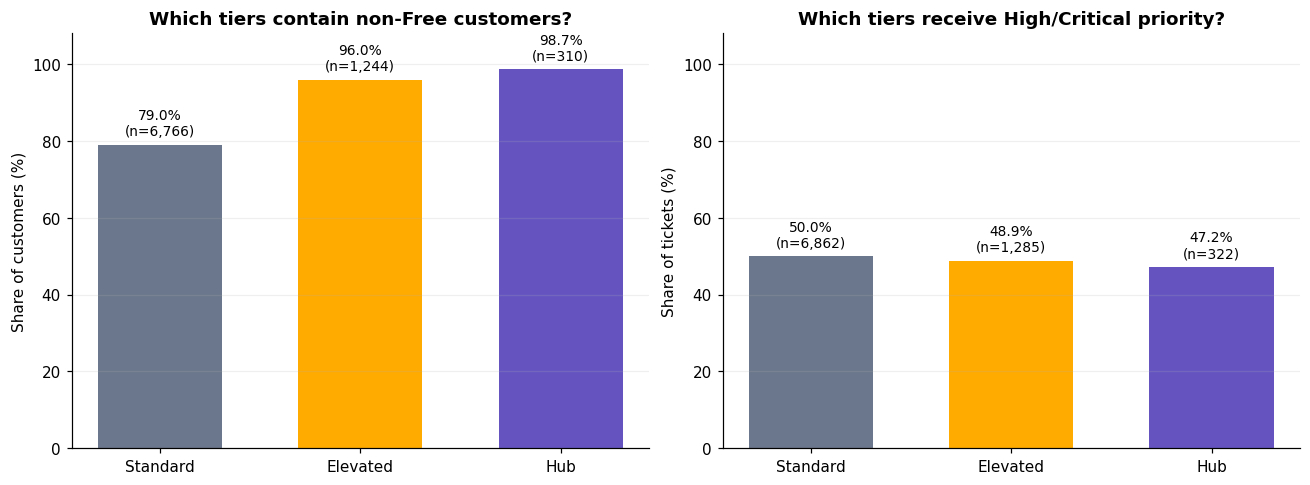

,customers,non_free_rate,customer_share
collaboration_tier,,,
Standard,"6,766",79.0%,81.3%
Elevated,"1,244",96.0%,15.0%
Hub,310,98.7%,3.7%


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(11.8, 4.3), layout="constrained")
panels = [
    (axes[0], tier_customer["non_free_rate"], tier_customer["customers"],
     "Which tiers contain non-Free customers?", "Customers"),
    (axes[1], tier_ticket["high_priority_rate"], tier_ticket["tickets"],
     "Which tiers receive High/Critical priority?", "Tickets"),
]
for ax, rates, denominators, title, denominator_name in panels:
    bars = ax.bar(
        TIER_ORDER, rates * 100, color=[TIER_COLORS[tier] for tier in TIER_ORDER], width=.62,
    )
    labels = [f"{rate:.1%}\n(n={int(n):,})" for rate, n in zip(rates, denominators)]
    ax.bar_label(bars, labels=labels, padding=4, fontsize=9)
    ax.set(title=title, ylabel=f"Share of {denominator_name.lower()} (%)", ylim=(0, 108))
    ax.grid(axis="y", alpha=.2)
save_show(fig, "05_tier_relationships.png")
display(tier_customer.style.format({"customers": "{:,}", "non_free_rate": "{:.1%}", "customer_share": "{:.1%}"}))

In [6]:
display(Markdown(f'''**Observed:** Hub contains **{int(tier_customer.loc["Hub", "customers"]):,}
customers ({tier_customer.loc["Hub", "customer_share"]:.1%})** and
**{tier_customer.loc["Hub", "non_free_rate"]:.1%}** are non-Free. Yet only
**{tier_ticket.loc["Hub", "high_priority_rate"]:.1%} of Hub tickets
(n={int(tier_ticket.loc["Hub", "tickets"]):,})** are High/Critical.

**Meaning:** the tier summary preserves the mismatch and defines a manageable simulation population.

**Limitation:** non-Free is a commercial-plan proxy; the data contains no contract value or revenue.'''))

**Observed:** Hub contains **310
customers (3.7%)** and
**98.7%** are non-Free. Yet only
**47.2% of Hub tickets
(n=322)** are High/Critical.

**Meaning:** the tier summary preserves the mismatch and defines a manageable simulation population.

**Limitation:** non-Free is a commercial-plan proxy; the data contains no contract value or revenue.

## 4.4 Save for Downstream Stages

In [7]:
customer_view.to_parquet(ARTIFACTS / "customer_view.parquet")
ticket_view.to_parquet(ARTIFACTS / "ticket_view.parquet")
print("Saved: customer_view.parquet, ticket_view.parquet -> ./artifacts/ (now with tier columns)")

Saved: customer_view.parquet, ticket_view.parquet -> ./artifacts/ (now with tier columns)
